# Polyagamma GP Negative Binomial Demo

This notebook mirrors `pg_classifier_demo.ipynb`, but uses the new fixed-`r` negative-binomial PG model.

The setup stays close to the toy-data pattern in `PG_GP4.ipynb`:

- random points in `[-1, 1]^2`,
- a latent GP sample `f`,
- counts drawn from a negative binomial likelihood with fixed total-count parameter `r` and logits `f`.


In [41]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.distributions import NegativeBinomial

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

ROOT = Path.cwd().resolve()
PARENT = ROOT.parent
if str(PARENT) not in sys.path:
    sys.path.append(str(PARENT))

from vanilla_gp_sampling import sample_gp_fast, squared_exponential_kernel
from pg_classifier import PolyagammaGPNegativeBinomialRegressor

torch.set_default_dtype(torch.float64)
torch.manual_seed(7)
np.random.seed(7)

plt.style.use("seaborn-v0_8-whitegrid")


## Generate The Same Style Of Toy Data As `PG_GP4.ipynb`

We keep the same 2D random-input construction. The only difference is the observation model: instead of Bernoulli draws, we sample negative-binomial counts with fixed `r` and logits given by the latent GP.


In [42]:
n_train = 100
d = 2
true_length_scale = 0.8
true_variance = 1.0
total_count = 3.0
grid_size = 24

X_train = torch.rand(n_train, d) * 2.0 - 1.0
grid_1d = torch.linspace(-1.1, 1.1, grid_size)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="ij")
X_grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

X_all = torch.cat([X_train, X_grid], dim=0)
f_all = sample_gp_fast(
    X_all,
    num_samples=1,
    length_scale=true_length_scale,
    variance=true_variance,
    noise_variance=1e-4,
)
y_all = NegativeBinomial(
    total_count=torch.tensor(total_count, dtype=torch.float64),
    logits=f_all,
).sample()

y_train = y_all[:n_train]
f_train_true = f_all[:n_train]
f_grid_true = f_all[n_train:]
mean_count_grid_true = total_count * torch.exp(f_grid_true)

X_train_np = X_train.cpu().numpy()
y_train_np = y_train.cpu().numpy().astype(np.float64)
X_grid_np = X_grid.cpu().numpy()
grid_1d_np = grid_1d.cpu().numpy()

print(f"Training points: {n_train}")
print(f"Grid points: {X_grid_np.shape[0]}")
print(f"Fixed total_count r: {total_count:.1f}")
print(f"Mean observed count: {y_train_np.mean():.3f}")


Training points: 100
Grid points: 576
Fixed total_count r: 3.0
Mean observed count: 2.490


## Fit `PolyagammaGPNegativeBinomialRegressor`

This uses the same PG spectral code path as the Bernoulli model. Only the likelihood-dependent E-step scalars change: `\kappa`, the PG `b` parameter, and the `E[\omega]` update.


In [43]:
reg = PolyagammaGPNegativeBinomialRegressor(
    total_count=total_count,
    lengthscale_init=0.30,
    variance_init=1.00,
    max_iter=50,
    e_step_iters=1,
    final_e_step_iters=2,
    rho0=0.7,
    gamma=1e-3,
    lr=0.05,
    n_e_probes=1,
    n_m_probes=1,
    cg_tol=1e-5,
    nufft_eps=1e-4,
    spectral_eps=1e-4,
    trunc_eps=1e-4,
    prediction_batch_size=96,
    use_toeplitz_warm_start=False,
    random_state=0,
    device="cpu",
    store_history=True,
    verbose=0,
)

t0 = time.time()
reg.fit(X_train_np, y_train_np)
fit_time = time.time() - t0

print(f"Fit time: {fit_time:.2f} s")
print(f"Learned lengthscale: {reg.lengthscale_:.4f}")
print(f"Learned variance: {reg.variance_:.4f}")
print(f"Training mean absolute error: {reg.training_mean_absolute_error_:.3f}")


Fit time: 8.46 s
Learned lengthscale: 0.7400
Learned variance: 0.8120
Training mean absolute error: 1.555


In [44]:
latent_train = reg.decision_function(X_train_np)
var_train = reg.predictive_variance(X_train_np)
mean_count_train = reg.predict_mean_count(X_train_np)

latent_grid = reg.decision_function(X_grid_np)
var_grid = reg.predictive_variance(X_grid_np)
mean_count_grid = reg.predict_mean_count(X_grid_np)

f_grid_true_img = f_grid_true.cpu().numpy().reshape(grid_size, grid_size)
mean_count_grid_true_img = mean_count_grid_true.cpu().numpy().reshape(grid_size, grid_size)
latent_grid_img = latent_grid.reshape(grid_size, grid_size)
mean_count_grid_img = mean_count_grid.reshape(grid_size, grid_size)
var_grid_img = var_grid.reshape(grid_size, grid_size)

probe_points = np.array([
    [-0.75, -0.75],
    [0.00, 0.00],
    [0.75, 0.75],
], dtype=np.float64)
probe_summary = np.column_stack(
    [
        probe_points,
        reg.decision_function(probe_points),
        reg.predictive_variance(probe_points),
        reg.predict_mean_count(probe_points),
    ]
)

print("Columns: x1, x2, latent_mean, latent_variance, predicted_mean_count")
np.round(probe_summary, 3)


Columns: x1, x2, latent_mean, latent_variance, predicted_mean_count


array([[-0.75 , -0.75 ,  0.59 ,  0.061,  5.578],
       [ 0.   ,  0.   , -0.753,  0.056,  1.453],
       [ 0.75 ,  0.75 ,  0.006,  0.053,  3.099]])

Text(0.5, 0.98, 'Polyagamma GP Negative Binomial Demo')

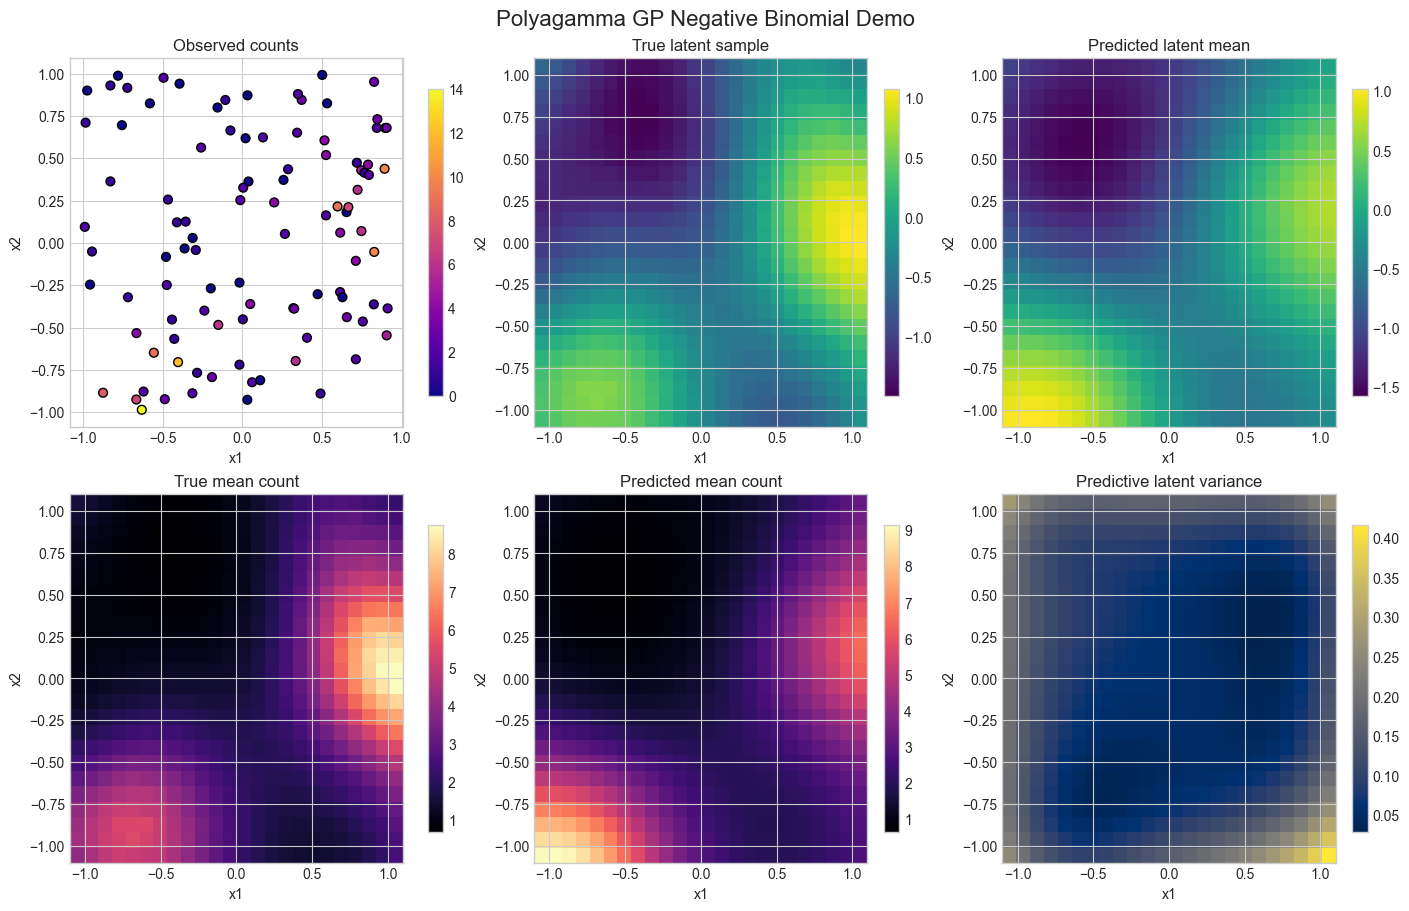

In [45]:
extent = [grid_1d_np.min(), grid_1d_np.max(), grid_1d_np.min(), grid_1d_np.max()]

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

scatter = axes[0, 0].scatter(
    X_train_np[:, 0],
    X_train_np[:, 1],
    c=y_train_np,
    cmap="plasma",
    s=40,
    edgecolors="black",
)
axes[0, 0].set_title("Observed counts")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")
fig.colorbar(scatter, ax=axes[0, 0], fraction=0.046)

im = axes[0, 1].imshow(
    f_grid_true_img.T,
    origin="lower",
    extent=extent,
    cmap="viridis",
    aspect="auto",
)
# axes[0, 1].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="plasma", s=12, edgecolors="black")
axes[0, 1].set_title("True latent sample")
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_ylabel("x2")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046)

im = axes[0, 2].imshow(
    latent_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="viridis",
    aspect="auto",
)
# axes[0, 2].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="plasma", s=12, edgecolors="black")
axes[0, 2].set_title("Predicted latent mean")
axes[0, 2].set_xlabel("x1")
axes[0, 2].set_ylabel("x2")
fig.colorbar(im, ax=axes[0, 2], fraction=0.046)

im = axes[1, 0].imshow(
    mean_count_grid_true_img.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
)
# axes[1, 0].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="plasma", s=12, edgecolors="black")
axes[1, 0].set_title("True mean count")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 0], fraction=0.046)

im = axes[1, 1].imshow(
    mean_count_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
)
# axes[1, 1].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="plasma", s=12, edgecolors="black")
axes[1, 1].set_title("Predicted mean count")
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046)

im = axes[1, 2].imshow(
    var_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="cividis",
    aspect="auto",
)
# axes[1, 2].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="plasma", s=12, edgecolors="black")
axes[1, 2].set_title("Predictive latent variance")
axes[1, 2].set_xlabel("x1")
axes[1, 2].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 2], fraction=0.046)

fig.suptitle("Polyagamma GP Negative Binomial Demo", fontsize=16)


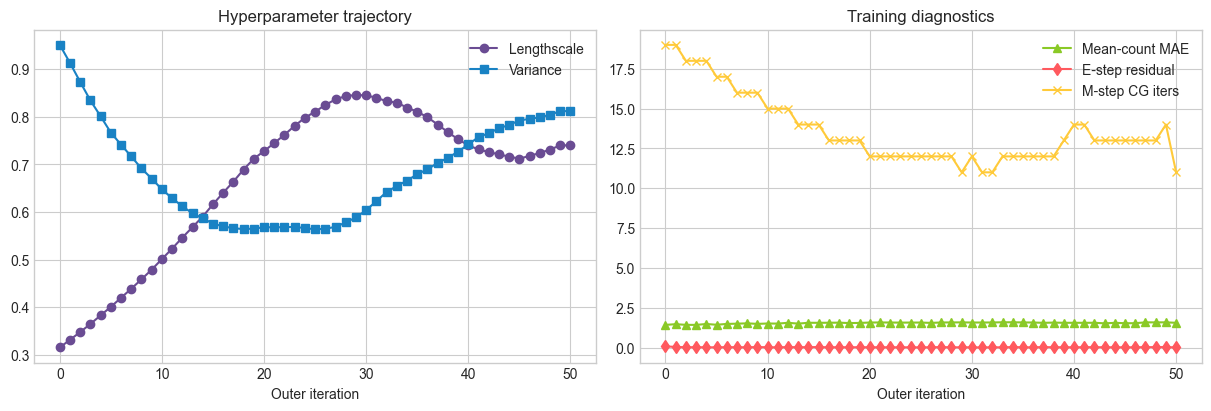

In [46]:
history = reg.history_
iters = np.array([row["iter"] for row in history], dtype=float)
lengthscales = np.array([row["lengthscale"] for row in history], dtype=float)
variances = np.array([row["variance"] for row in history], dtype=float)
count_mae = np.array([row["mean_count_mae"] for row in history], dtype=float)
e_residuals = np.array([row["e_residual"] for row in history], dtype=float)
m_cg_iters = np.array([row["m_cg_iters"] for row in history], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(iters, lengthscales, marker="o", color="#6a4c93", label="Lengthscale")
axes[0].plot(iters, variances, marker="s", color="#1982c4", label="Variance")
axes[0].set_title("Hyperparameter trajectory")
axes[0].set_xlabel("Outer iteration")
axes[0].legend(loc="best")

axes[1].plot(iters, count_mae, marker="^", color="#8ac926", label="Mean-count MAE")
axes[1].plot(iters, e_residuals, marker="d", color="#ff595e", label="E-step residual")
axes[1].plot(iters, m_cg_iters, marker="x", color="#ffca3a", label="M-step CG iters")
axes[1].set_title("Training diagnostics")
axes[1].set_xlabel("Outer iteration")
axes[1].legend(loc="best")


## Exact Dense Latent Log-Density Sanity Check

For the negative-binomial model, the exact observed-data marginal $p(y \mid \theta)$ is not available in closed form. As a sanity check, we instead evaluate the exact dense GP log density of the sampled training latent $f_{\mathrm{train}}$ under the analytic squared-exponential kernel, and overlay the learned hyperparameter path from the PG optimizer.


Final PG iterate: lengthscale=0.740, variance=0.812
True hyperparams: lengthscale=0.800, variance=1.000


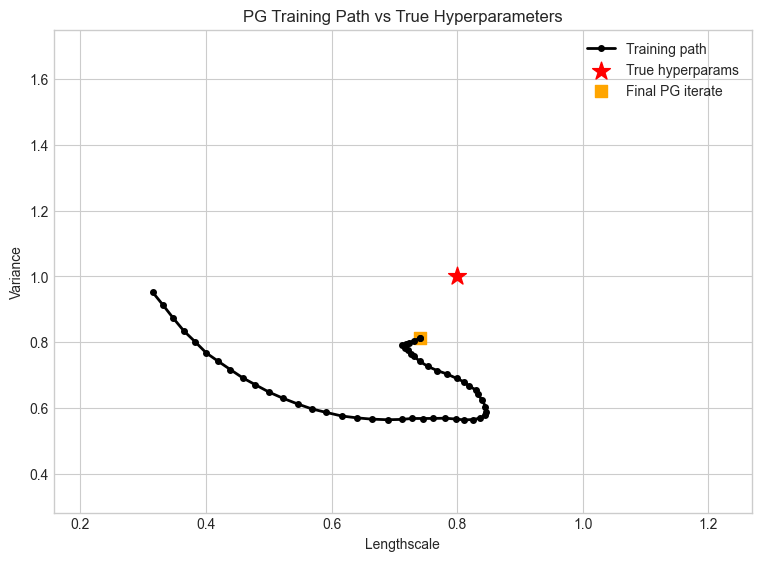

In [47]:
def exact_latent_log_density(X, f, lengthscale, variance, jitter=1e-6):
    K = squared_exponential_kernel(X, X, length_scale=float(lengthscale), variance=float(variance))
    K = K + jitter * torch.eye(X.shape[0], dtype=X.dtype, device=X.device)
    L = torch.linalg.cholesky(K)
    alpha = torch.cholesky_solve(f.unsqueeze(-1), L).squeeze(-1)
    logdet = 2.0 * torch.sum(torch.log(torch.diagonal(L)))
    n = X.shape[0]
    return float(-0.5 * (torch.dot(f, alpha) + logdet + n * np.log(2.0 * np.pi)))

ls_min = max(0, min(lengthscales.min(), true_length_scale) * 0.5)
ls_max = max(lengthscales.max(), true_length_scale) * 1.5
var_min = max(0, min(variances.min(), true_variance) * 0.5)
var_max = max(variances.max(), true_variance) * 1.75

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
ax.plot(lengthscales, variances, color="black", linewidth=2, marker="o", markersize=4, label="Training path")
ax.scatter([true_length_scale], [true_variance], color="red", marker="*", s=180, label="True hyperparams")
ax.scatter([lengthscales[-1]], [variances[-1]], color="orange", marker="s", s=70, label="Final PG iterate")
ax.set_xlabel("Lengthscale")
ax.set_ylabel("Variance")
ax.set_title("PG Training Path vs True Hyperparameters")
ax.legend(loc="best")
ax.set_xlim(ls_min, ls_max)
ax.set_ylim(var_min, var_max)

print(f"Final PG iterate: lengthscale={lengthscales[-1]:.3f}, variance={variances[-1]:.3f}")
print(f"True hyperparams: lengthscale={true_length_scale:.3f}, variance={true_variance:.3f}")


In [48]:
print("First five observed counts:", y_train_np[:5].astype(int))
print("First five predicted mean counts:", np.round(mean_count_train[:5], 3))
print("First five training variances:", np.round(var_train[:5], 3))
print("First five latent predictions:", np.round(latent_train[:5], 3))


First five observed counts: [1 6 2 1 4]
First five predicted mean counts: [2.53  4.479 3.883 0.918 2.774]
First five training variances: [0.11  0.093 0.112 0.058 0.037]
First five latent predictions: [-0.225  0.355  0.202 -1.213 -0.097]
